In [173]:
########################################
####  PROCESS DATA | PICKLE TO EDA  ####
########################################
import re
from collections import defaultdict
import pyreadstat
import pandas as pd
import pickle
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [153]:
with open('years_levels_data.pkl', 'rb') as f:
    year_dfs = pickle.load(f)

In [154]:
for year in sorted(year_dfs.keys()):
    for level in sorted(year_dfs[year].keys()):
        shape = year_dfs[year][level].shape
        print(f'{year} | {level} | {shape}')

2015 | A | (13833, 18)
2015 | B | (13833, 21)
2015 | C | (13833, 28)
2015 | D | (13833, 18)
2015 | E | (13833, 17)
2015 | F | (13833, 31)
2015 | G | (13833, 19)
2015 | H | (13833, 29)
2015 | I | (13833, 24)
2015 | J | (13833, 24)
2015 | K | (13833, 18)
2015 | L | (13833, 33)
2015 | M | (13833, 16)
2015 | N | (13833, 21)
2015 | O | (13833, 16)
2015 | P | (13833, 30)
2015 | Q | (13833, 31)
2015 | R | (13833, 19)
2015 | S | (13833, 24)
2015 | T | (13833, 17)
2015 | U | (13833, 38)
2016 | A | (13303, 39)
2016 | B | (13303, 44)
2016 | C | (13303, 50)
2016 | D | (13303, 39)
2016 | E | (13303, 42)
2016 | F | (13303, 52)
2016 | G | (13303, 40)
2016 | H | (13303, 51)
2016 | I | (13303, 45)
2016 | J | (13303, 45)
2016 | K | (13303, 39)
2016 | L | (13303, 54)
2016 | M | (13303, 37)
2016 | N | (13303, 42)
2016 | O | (13303, 37)
2016 | P | (13303, 63)
2016 | Q | (13303, 52)
2016 | R | (13303, 40)
2016 | S | (13303, 45)
2016 | T | (13303, 38)
2016 | U | (13303, 59)
2017 | A | (11390, 43)
2017 | B | 

In [155]:
#### Use 2022 data ####
df = year_dfs[2022]['F']
print(df.isnull().sum())

MEMS7GR_ALL                   0
wt_final                      0
wt_time                       0
xStrata                       0
Reg9                          0
                             ..
MONTHS_12_DODGEBALL_F12       0
MONTHS_12_BASESOFTBALL_F13    0
MONTHS_12_LACROSSE_F14        0
MONTHS_12_GOALBALL_F15        0
MONTHS_12_HANDBALL_F16        0
Length: 62, dtype: int64


In [156]:
#### Drop Columns ####
df.drop(columns=['LondInOut', 'motive_POP'], inplace=True, errors='ignore')

#### 0 Fill Columns ####
vol_cols = ['VolAny', 'VolFrqB_Pop', 'VolCnt', 'volint1', 'volint2', 'volint3', 'volint4', 'volint5', 'volint6', 'volint7']
vol_cols = [c for c in vol_cols if c in df.columns]
df[vol_cols] = df[vol_cols].fillna(0)

In [157]:
exclude_from_pca = [
    'MEMS7GR_ALL',          # outcome
    'wt_final', 'wt_time', 'xStrata',  # weights/design
    'Reg9', 'LA_2023',      # geography
    'happy', 'lifesat', 'worthw', 'anxious',  # wellbeing - keep for later
    'DURATION_SPORTCOUNT_A01',  # used for filtering, not a feature
    'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01',  # MEMS - multicollinearity risk
]
pca_cols = [c for c in df.columns if c not in exclude_from_pca]

In [158]:
print(pca_cols)

['IMD10', 'Motiva_POP', 'motivb_POP', 'motivc_POP', 'motivd_POP', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'VolAny', 'VolFrqB_Pop', 'VolCnt', 'volint1', 'volint2', 'volint3', 'volint4', 'volint5', 'volint6', 'volint7', 'WHOWITHA_SPORTCOUNT_A01', 'WHOWITHB_SPORTCOUNT_A01', 'WHOWITHC_SPORTCOUNT_A01', 'WHOWITHD_SPORTCOUNT_A01', 'Disab3', 'Gend3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'Relig7', 'Orient4', 'MONTHS_12_FOOTBALL_F01', 'MONTHS_12_CRICKET_F02', 'MONTHS_12_RUGBYUNION_F03', 'MONTHS_12_RUGBYLEAGUE_F04', 'MONTHS_12_WHEELCHRUGBY_F05', 'MONTHS_12_NETBALL_F06', 'MONTHS_12_BASKETBALL_F07', 'MONTHS_12_WHEELCHBASKETBALL_F08', 'MONTHS_12_HOCKEY_F09', 'MONTHS_12_VOLLEYBALL_F10', 'MONTHS_12_ROUNDERS_F11', 'MONTHS_12_DODGEBALL_F12', 'MONTHS_12_BASESOFTBALL_F13', 'MONTHS_12_LACROSSE_F14', 'MONTHS_12_GOALBALL_F15', 'MONTHS_12_HANDBALL_F16']


In [159]:
df_encoded = pd.get_dummies(df[pca_cols], columns=['Disab3', 'Gend3', 'Eth7', 'Relig7', 'Orient4'])

In [160]:
df_encoded = df_encoded.fillna(df_encoded.median())

In [161]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

In [162]:
pca = PCA()
df_pca = pca.fit_transform(df_scaled)

In [163]:
print(np.cumsum(pca.explained_variance_ratio_))

[0.08474793 0.13318572 0.17594637 0.2155071  0.24875012 0.28131187
 0.30828825 0.3344495  0.35851857 0.38094013 0.40175922 0.42076136
 0.43908431 0.45732025 0.47512029 0.49276914 0.50998989 0.52681973
 0.54344426 0.55936073 0.57517511 0.59091793 0.60637041 0.62149827
 0.636456   0.65102463 0.66526849 0.67938066 0.69315538 0.70678006
 0.72007094 0.73326934 0.74631856 0.75906225 0.7716933  0.78417511
 0.79641616 0.80862675 0.82072091 0.83226595 0.84365265 0.85487086
 0.86587708 0.87647103 0.88680374 0.89695907 0.90686779 0.9165468
 0.92572032 0.9346082  0.9433213  0.95164038 0.9593564  0.9664007
 0.9732151  0.97901489 0.98418642 0.98917183 0.99402593 0.99608508
 0.9978447  0.99907814 0.99997358 1.         1.         1.
 1.        ]


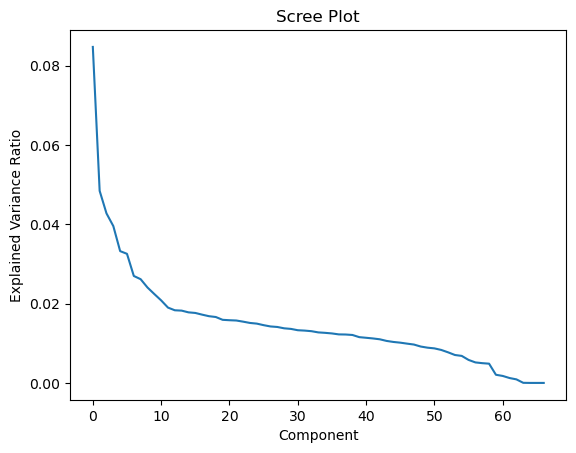

In [164]:
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()

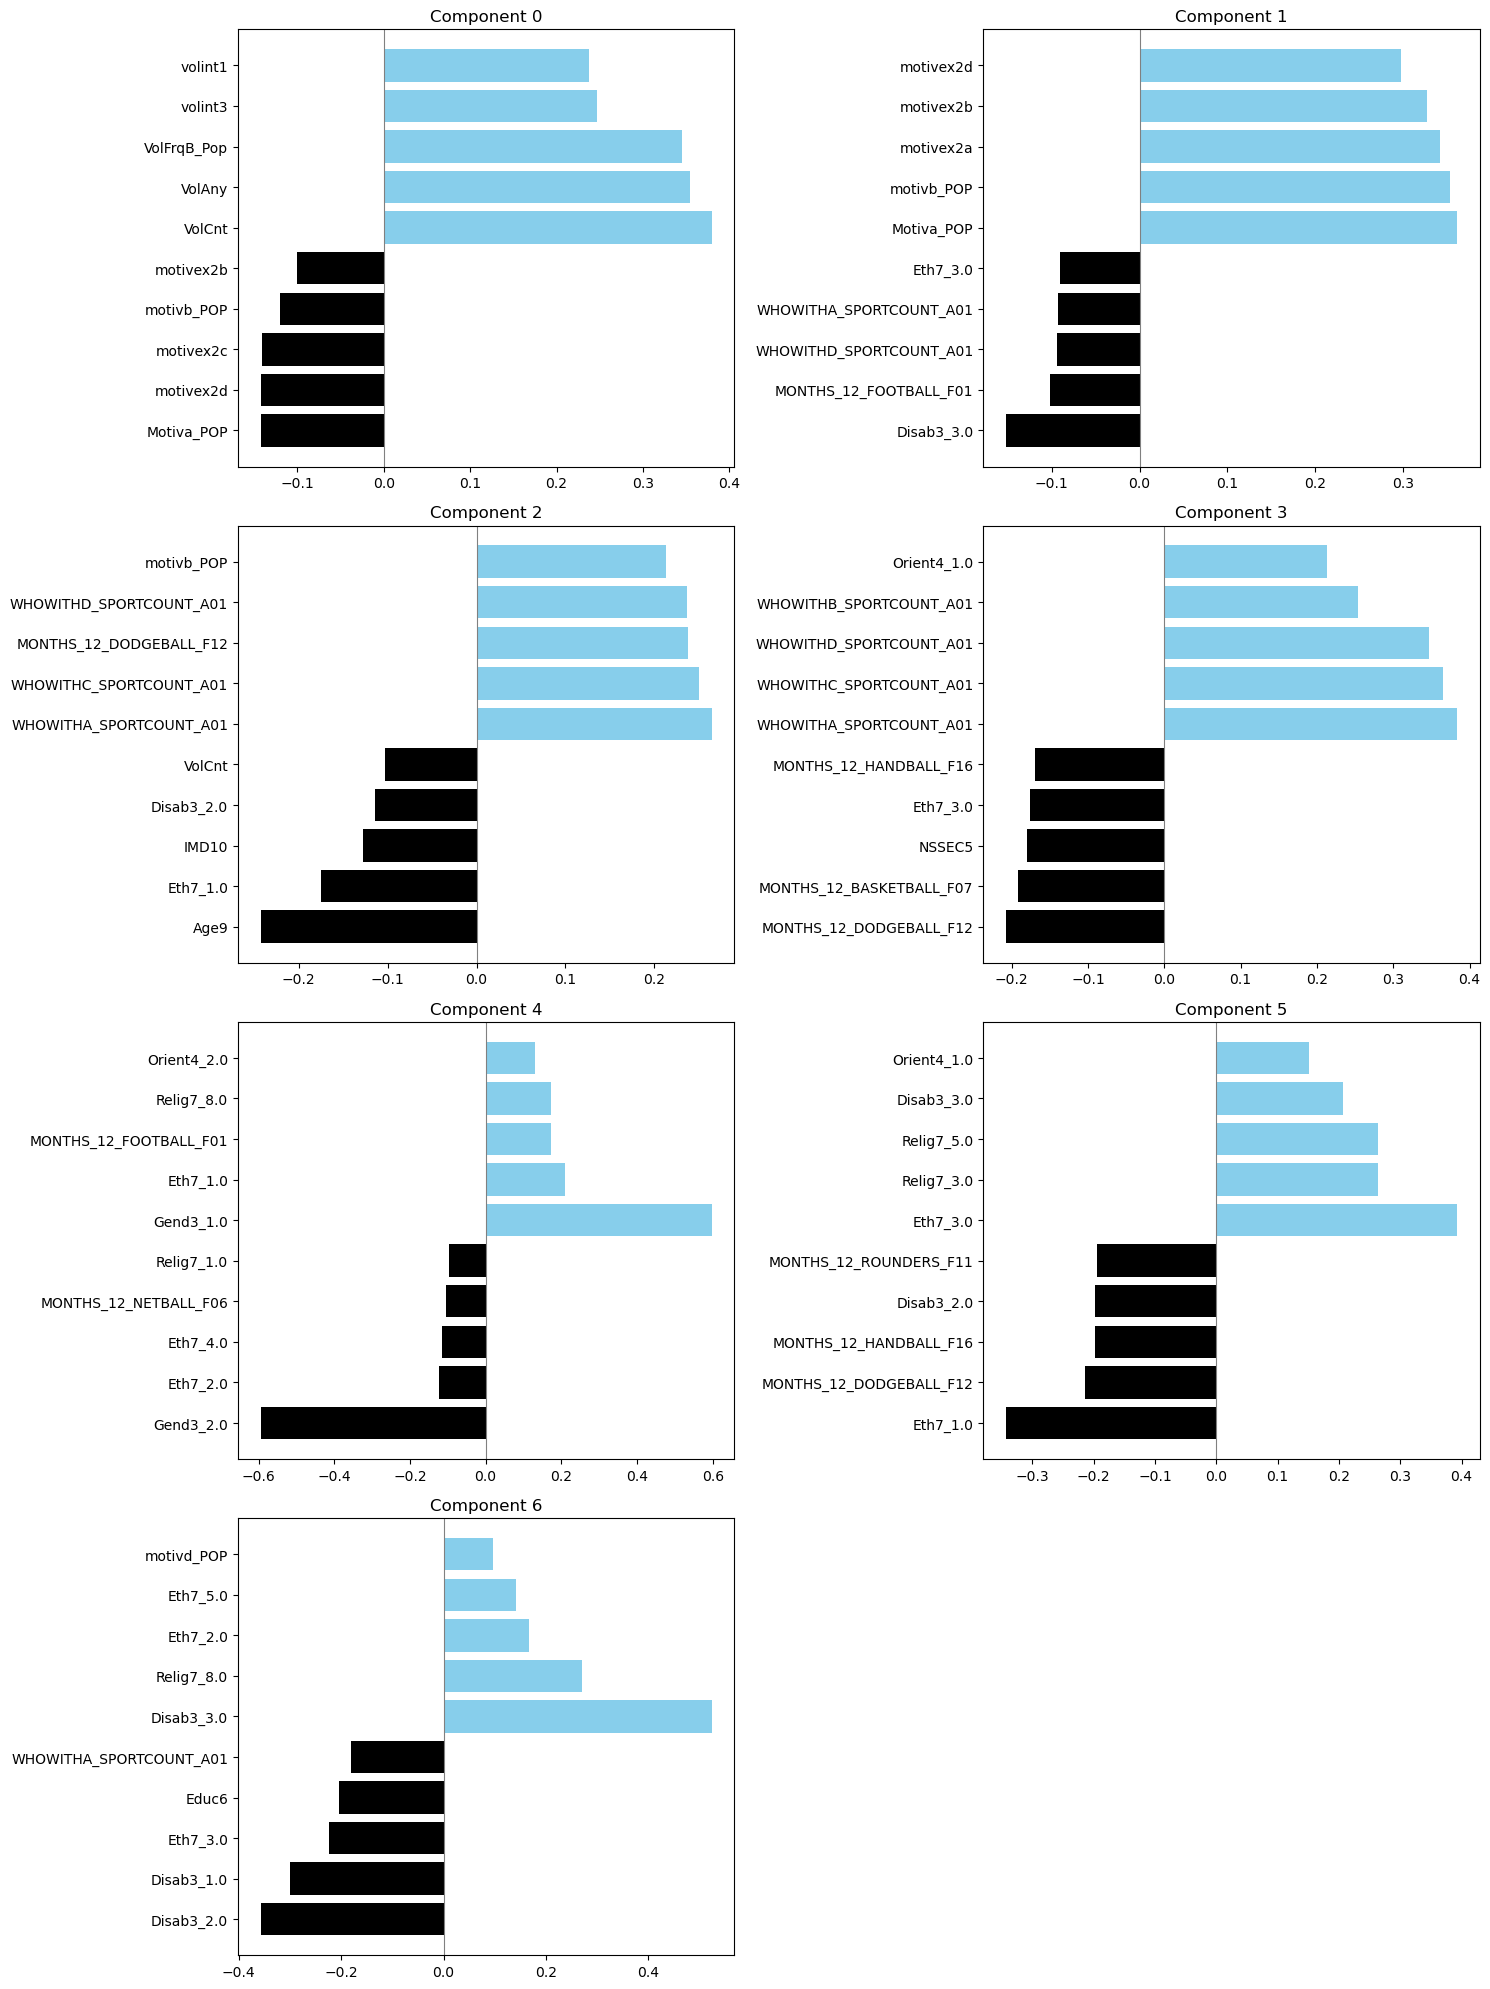

In [165]:
###############
####  PCA  ####
###############
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for c in range(7):
    s = pd.Series(pca.components_[c], index=df_encoded.columns)
    combined = pd.concat([s.sort_values().head(5), s.sort_values(ascending=False).head(5)])
    colors = ['black' if v < 0 else 'skyblue' for v in combined.values]
    axes[c].barh(combined.index, combined.values, color=colors)
    axes[c].set_title(f'Component {c}')
    axes[c].axvline(x=0, color='grey', linewidth=0.8)

axes[7].set_visible(False)
plt.tight_layout()
plt.show()

In [172]:
df = df.drop(columns=['LondInOut', 'motive_POP'], errors='ignore')

vol_cols = ['VolAny', 'VolFrqB_Pop', 'VolCnt', 'volint1', 'volint2', 'volint3', 'volint4', 'volint5', 'volint6', 'volint7']
vol_cols = [c for c in vol_cols if c in df.columns]
df[vol_cols] = df[vol_cols].fillna(0)

exclude_from_pca = ['MEMS7GR_ALL', 'wt_final', 'wt_time', 'xStrata', 'Reg9', 'LA_2023', 'happy', 'lifesat', 'worthw', 'anxious', 'DURATION_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_OUT_SPORTCOUNT_A01']
pca_cols = [c for c in df.columns if c not in exclude_from_pca]

df_encoded = pd.get_dummies(df[pca_cols], columns=['Disab3', 'Gend3', 'Eth7', 'Relig7', 'Orient4'])
df_encoded = df_encoded.fillna(df_encoded.median())

X = df_encoded
y = df['MEMS7GR_ALL']

In [174]:
scaler_pls = StandardScaler()
X = scaler_pls.fit_transform(X)

pls = PLSRegression(n_components=7)
pls.fit(X, y)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",7
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True


In [175]:
def calculate_vip(pls):
    W = pls.x_weights_
    Q = pls.y_loadings_
    T = pls.x_scores_
    p = W.shape[0]
    SS = np.diag(T.T @ T @ Q.T @ Q)
    W_norm = W / np.sqrt(np.sum(W**2, axis=0))
    vip = np.sqrt(p * np.sum(SS * W_norm**2, axis=1) / np.sum(SS))
    return vip

vip_scores = calculate_vip(pls)
vip_series = pd.Series(vip_scores, index=df_encoded.columns).sort_values(ascending=False)